# Delta 训练天数探索

目标：在效果尽量不明显退化的前提下，寻找尽量少的训练日，并比较 `recent / random / volatility_stratified` 三种采样方式。

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

import matplotlib.pyplot as plt
import pandas as pd

from delta import (
    create_feature,
    create_y,
    get_trade_dates,
    split_dates_by_range,
    summarize_daily_volatility,
    assign_volatility_bins,
    sample_dates_by_volatility,
    run_training_subset_experiment,
    load_daily_sample_cache,
    concat_sample_cache,
    train_model,
    evaluate_model,
)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [6]:
instrument_id = '511090'
trade_ymd = '20260319'
y_window = 600
k = 3
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'stride': 1,

    'short_window': 300,
    'long_window': 600,
    'y_window': y_window,

    'open_threshold': 3,  
    'open_confidence': 0,  

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 600,
    
    'k_up': k,
    'k_down': k,
    'adverse_cusum_threshold': 6,
    'adverse_cusum_drift': 3,

    "stop_tighten_start": 6000,
    'stop_tighten_step' : 60,
    'stop_tighten_factor': 0.9,
    'stop_tighten_floor': 0.75,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [7]:
trade_dates = get_trade_dates()

train_candidate_dates, _, _ = split_dates_by_range(
    trade_dates,
    train_start='20250901',
    train_end='20260331',
)

_, valid_dates, _ = split_dates_by_range(
    trade_dates,
    valid_start='20260401',
    valid_end='20260423',
)

_, _, test_dates = split_dates_by_range(
    trade_dates,
    test_start='20260401',
    test_end='20260423',
)

print('训练候选天数:', len(train_candidate_dates))
print('验证集天数:', len(valid_dates))
print('测试集天数:', len(test_dates))

训练集: 20250901 ~ 20260331 (70天)
验证集: 无
测试集: 无
训练集: 无
验证集: 20260401 ~ 20260423 (9天)
测试集: 无
训练集: 无
验证集: 无
测试集: 20260401 ~ 20260423 (9天)
训练候选天数: 70
验证集天数: 9
测试集天数: 9


In [8]:
stats_df = summarize_daily_volatility(instrument_id, train_candidate_dates)
stats_df = assign_volatility_bins(stats_df, vol_col='realized_volatility', n_bins=5)
stats_df

,trade_ymd,n_snapshots,open_price,close_price,close_to_close_return,realized_volatility,intraday_std,normalized_range,vol_bucket
0,20250901,14402,120.260,120.626,0.003043,0.002997,0.000972,0.004249,3
1,20250903,14402,120.543,120.945,0.003335,0.003152,0.000960,0.004048,3
2,20250905,14402,121.117,120.206,-0.007522,0.003442,0.002509,0.008975,4
3,20250909,14402,119.901,119.753,-0.001234,0.003159,0.000566,0.002669,3
4,20250911,14402,118.890,118.476,-0.003482,0.003957,0.001373,0.007217,4
5,20250915,14402,118.920,119.242,0.002708,0.002863,0.000627,0.004028,2
6,20250917,14402,119.082,119.500,0.003510,0.003518,0.001211,0.005324,4
7,20250919,14402,119.173,118.525,-0.005437,0.003780,0.002474,0.008525,4
8,20250923,14402,118.560,118.194,-0.003087,0.003972,0.000803,0.004420,4
9,20250925,14402,117.350,117.775,0.003622,0.004312,0.001918,0.008010,4


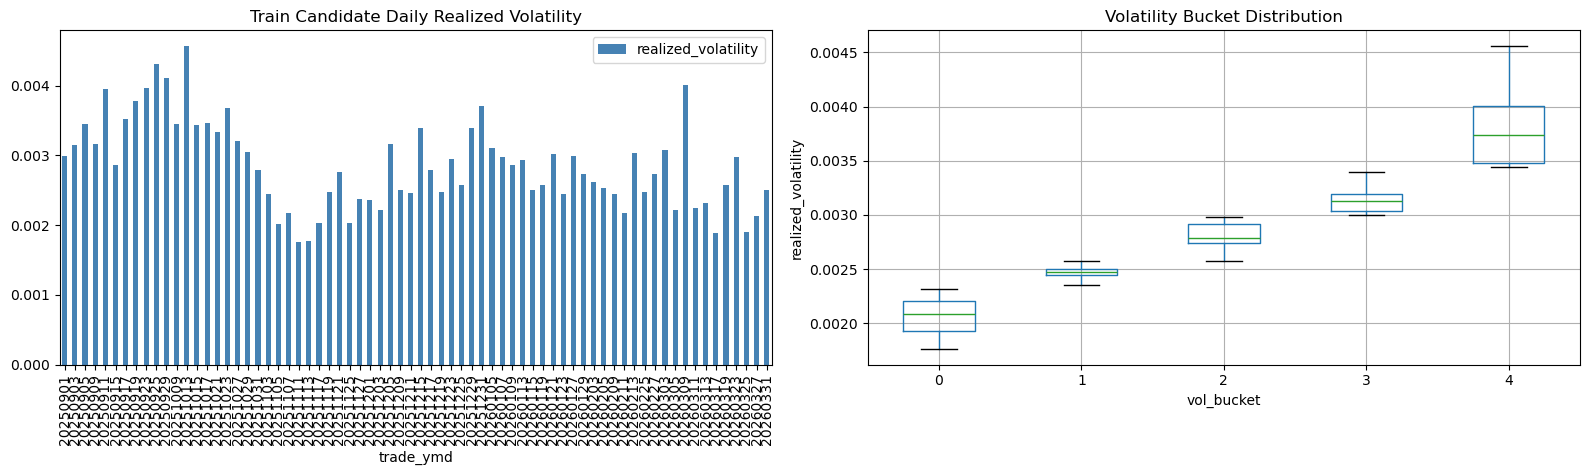

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stats_df.plot(
    x='trade_ymd',
    y='realized_volatility',
    kind='bar',
    ax=axes[0],
    color='steelblue',
    title='Train Candidate Daily Realized Volatility',
)
axes[0].tick_params(axis='x', rotation=90)

stats_df.boxplot(column='realized_volatility', by='vol_bucket', ax=axes[1])
axes[1].set_title('Volatility Bucket Distribution')
axes[1].set_xlabel('vol_bucket')
axes[1].set_ylabel('realized_volatility')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [10]:
train_day_grid = [4, 6, 8, 10, 12, 16, 20, 24, 32]

result_df, summary_df, stats_df = run_training_subset_experiment(
    instrument_id=instrument_id,
    train_candidate_dates=train_candidate_dates,
    valid_dates=valid_dates,
    test_dates=test_dates,
    param_dict=param_dict,
    feature_func=create_feature,
    y_func=create_y,
    train_day_grid=train_day_grid,
    strategies=('recent', 'random', 'volatility_stratified'),
    repeats=3,
    random_seed=42,
    n_bins=5,
)

summary_df

加载按天样本缓存...
20250901: 产生 274 个样本
20250903: 产生 297 个样本
20250905: 产生 268 个样本
20250909: 产生 282 个样本
20250911: 产生 243 个样本
20250915: 产生 270 个样本
20250917: 产生 249 个样本
20250919: 产生 275 个样本
20250923: 产生 274 个样本
20250925: 产生 286 个样本
20250929: 产生 276 个样本
20251009: 产生 279 个样本
20251013: 产生 230 个样本
20251015: 产生 240 个样本
20251017: 产生 240 个样本
20251021: 产生 296 个样本
20251023: 产生 256 个样本
20251027: 产生 276 个样本
20251029: 产生 284 个样本
20251031: 产生 282 个样本
20251103: 产生 288 个样本
20251105: 产生 282 个样本
20251107: 产生 275 个样本
20251111: 产生 274 个样本
20251113: 产生 288 个样本
20251117: 产生 309 个样本
20251119: 产生 279 个样本
20251121: 产生 276 个样本
20251125: 产生 282 个样本
20251127: 产生 302 个样本
20251201: 产生 324 个样本
20251203: 产生 334 个样本
20251205: 产生 275 个样本
20251209: 产生 292 个样本
20251211: 产生 301 个样本
20251215: 产生 304 个样本
20251217: 产生 292 个样本
20251219: 产生 295 个样本
20251223: 产生 296 个样本
20251225: 产生 340 个样本
20251229: 产生 261 个样本
20251231: 产生 285 个样本
20260105: 产生 308 个样本
20260107: 产生 286 个样本
20260109: 产生 275 个样本
20260113: 产生 273 个样本
20260115: 产生 305 个样本
2

,strategy,train_days,accuracy_mean,accuracy_std,f1_mean,f1_std,ap_mean,ap_std,pr_auc_mean,pr_auc_std,train_samples_mean
0,random,4,0.567703,0.042855,0.468722,0.012065,0.374914,0.028789,0.373944,0.028752,1177.333333
1,recent,4,0.601637,0.000000,0.458871,0.000000,0.378997,0.000000,0.377925,0.000000,1407.000000
2,volatility_stratified,4,0.560720,0.053861,0.448080,0.029320,0.354713,0.034077,0.353695,0.034220,1155.666667
3,random,6,0.612766,0.023060,0.452693,0.011173,0.380142,0.022982,0.379241,0.022946,1709.000000
4,recent,6,0.641244,0.000000,0.460630,0.000000,0.405498,0.000000,0.404273,0.000000,2053.000000
5,volatility_stratified,6,0.644081,0.003295,0.437741,0.021030,0.382726,0.005881,0.381770,0.005953,1761.333333
6,random,8,0.584506,0.066197,0.481786,0.001453,0.383275,0.038374,0.382418,0.038494,2307.666667
7,recent,8,0.676268,0.000000,0.427331,0.000000,0.412117,0.000000,0.410887,0.000000,2717.000000
8,volatility_stratified,8,0.631860,0.053065,0.465894,0.046385,0.393688,0.020363,0.392808,0.020274,2373.000000
9,random,10,0.587889,0.090777,0.486461,0.010093,0.393434,0.042482,0.392546,0.042719,2954.000000


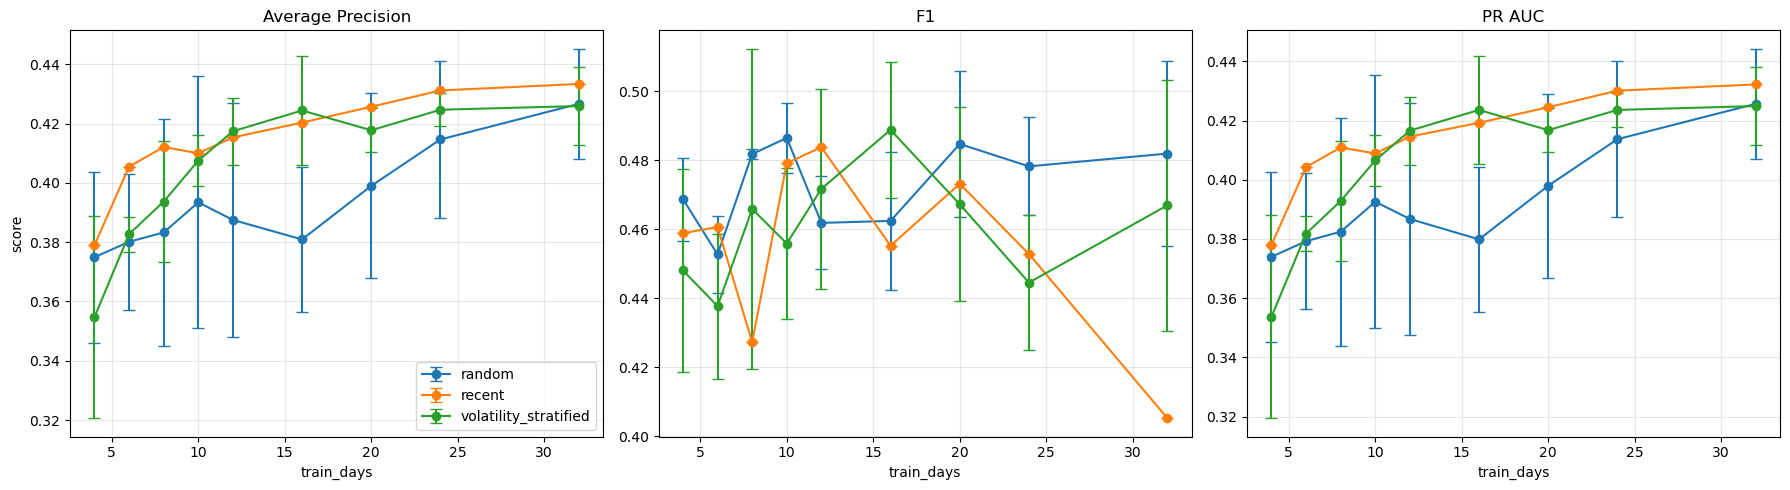

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
metric_pairs = [
    ('ap_mean', 'ap_std', 'Average Precision'),
    ('f1_mean', 'f1_std', 'F1'),
    ('pr_auc_mean', 'pr_auc_std', 'PR AUC'),
]

for ax, (mean_col, std_col, title) in zip(axes, metric_pairs):
    for strategy_name, part in summary_df.groupby('strategy'):
        ax.errorbar(
            part['train_days'],
            part[mean_col],
            yerr=part[std_col],
            marker='o',
            capsize=4,
            label=strategy_name,
        )
    ax.set_title(title)
    ax.set_xlabel('train_days')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('score')
axes[0].legend()
plt.tight_layout()
plt.show()

In [12]:
target_metric = 'ap_mean'
retain_ratio = 0.98

best_score = summary_df[target_metric].max()
candidate_summary = summary_df[summary_df[target_metric] >= best_score * retain_ratio].copy()
recommended_row = candidate_summary.sort_values(['train_days', target_metric], ascending=[True, False]).iloc[0]
recommended_row

strategy                recent
train_days                  20
accuracy_mean          0.66252
accuracy_std               0.0
f1_mean               0.473173
f1_std                     0.0
ap_mean               0.425696
ap_std                     0.0
pr_auc_mean            0.42448
pr_auc_std                 0.0
train_samples_mean      6705.0
Name: 19, dtype: object

In [13]:
recommended_days = int(recommended_row['train_days'])
recommended_dates = sample_dates_by_volatility(
    stats_df,
    sample_size=recommended_days,
    random_seed=42,
    n_bins=5,
)
recommended_dates

['20250903',
 '20250915',
 '20251015',
 '20251017',
 '20251027',
 '20251029',
 '20251103',
 '20251105',
 '20251107',
 '20251119',
 '20251121',
 '20251201',
 '20251223',
 '20260105',
 '20260129',
 '20260205',
 '20260213',
 '20260309',
 '20260313',
 '20260331']

20250903: 产生 297 个样本
20250915: 产生 270 个样本
20251015: 产生 240 个样本
20251017: 产生 240 个样本
20251027: 产生 276 个样本
20251029: 产生 284 个样本
20251103: 产生 288 个样本
20251105: 产生 282 个样本
20251107: 产生 275 个样本
20251119: 产生 279 个样本
20251121: 产生 276 个样本
20251201: 产生 324 个样本
20251223: 产生 296 个样本
20260105: 产生 308 个样本
20260129: 产生 327 个样本
20260205: 产生 345 个样本
20260213: 产生 310 个样本
20260309: 产生 316 个样本
20260313: 产生 333 个样本
20260331: 产生 342 个样本
20260401: 产生 356 个样本
20260403: 产生 364 个样本
20260407: 产生 330 个样本
20260409: 产生 379 个样本
20260413: 产生 357 个样本
20260415: 产生 352 个样本
20260417: 产生 320 个样本
20260421: 产生 302 个样本
20260423: 产生 295 个样本
训练 xgboost 模型...
[0]	validation_0-logloss:0.69243
[100]	validation_0-logloss:0.66856
[200]	validation_0-logloss:0.66829
[300]	validation_0-logloss:0.66926
[400]	validation_0-logloss:0.66901
[500]	validation_0-logloss:0.66983
[600]	validation_0-logloss:0.66876
[700]	validation_0-logloss:0.66803
[800]	validation_0-logloss:0.66687
[900]	validation_0-logloss:0.66698
[999]	validation_0-logloss

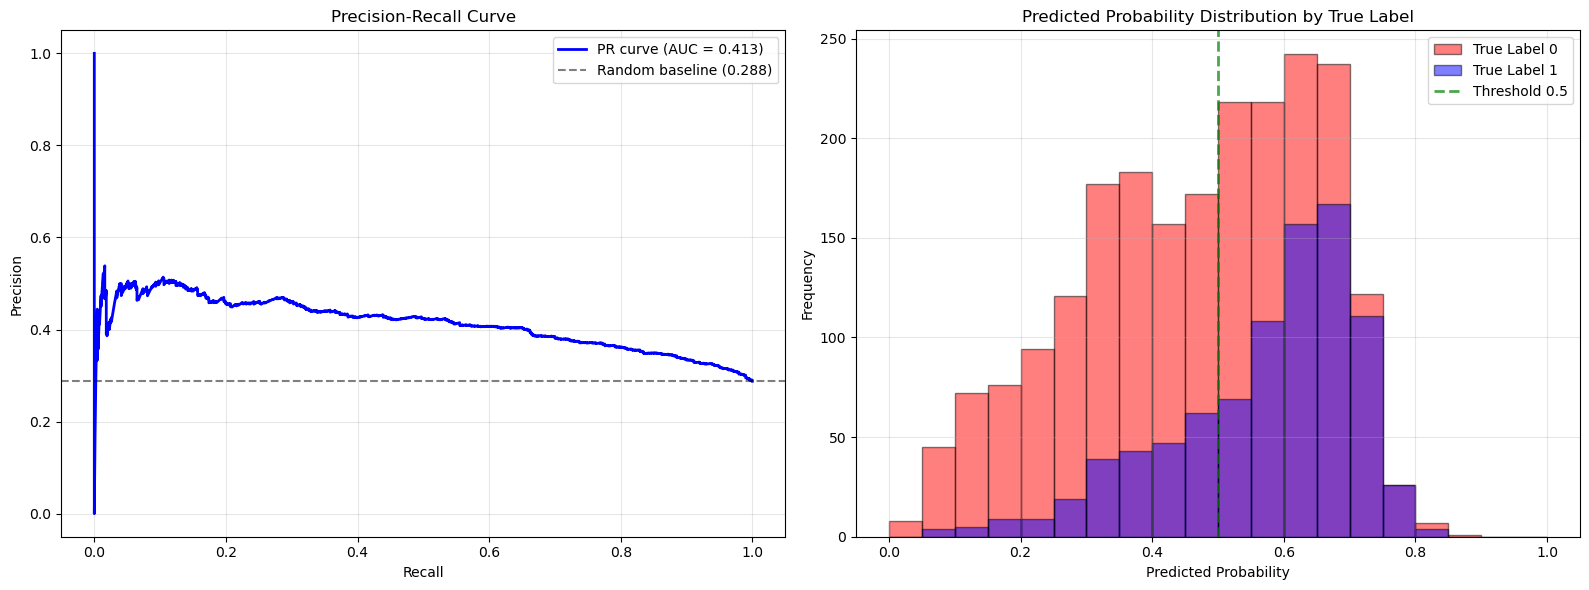

0.6572831423895253

In [14]:
cache_dates = sorted(set(recommended_dates) | set(valid_dates) | set(test_dates))
sample_cache = load_daily_sample_cache(
    cache_dates,
    instrument_id,
    param_dict,
    create_feature,
    create_y,
)

X_train, y_train, feature_names = concat_sample_cache(sample_cache, recommended_dates)
X_valid, y_valid, _ = concat_sample_cache(sample_cache, valid_dates)
X_test, y_test, _ = concat_sample_cache(sample_cache, test_dates)

model = train_model(X_train, y_train, X_valid, y_valid, param_dict, feature_names)
evaluate_model(model, X_test, y_test, show_plots=True)

结论建议：

1. 先看 `summary_df` 中 `volatility_stratified` 在小样本训练日下是否显著优于 `recent/random`。
2. 再结合 `retain_ratio` 调整“接近最优”的容忍度，例如 `0.97 ~ 0.99`。
3. 如果最终策略仍要上线，建议把推荐训练日固定为一个可复现的日期列表，而不是每次重新随机抽样。